In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_df = pd.read_csv("C:/01_Data/PythonProgram/Toxic_Comment_Classification_PROJECT/train_data/train.csv")

In [5]:
print("TOXICITY OVERVIEW")
toxic_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Check if comment has ANY toxic label
has_toxic = train_df[toxic_columns].sum(axis=1) > 0
toxic_count = has_toxic.sum()
non_toxic_count = len(train_df) - toxic_count

print(f"TOTAL COMMENTS: {len(train_df):,}")
print(f"NON-TOXIC: {non_toxic_count:,} ({non_toxic_count/len(train_df)*100:.1f}%)")
print(f"TOXIC: {toxic_count:,} ({toxic_count/len(train_df)*100:.1f}%)")

TOXICITY OVERVIEW
TOTAL COMMENTS: 159,571
NON-TOXIC: 143,346 (89.8%)
TOXIC: 16,225 (10.2%)


<Axes: >

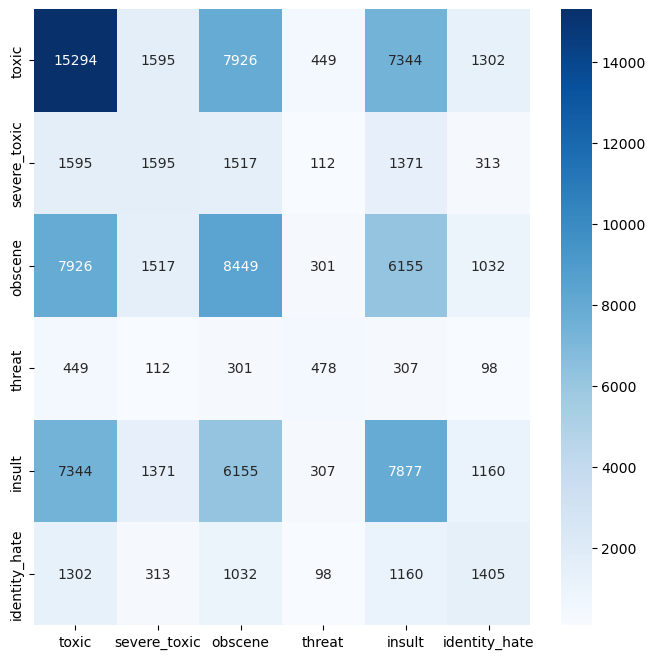

In [11]:
co_occurrence=train_df[toxic_columns].T.dot(train_df[toxic_columns])
plt.figure(figsize=(8,8))
sns.heatmap(co_occurrence, annot=True, cmap='Blues',fmt='d')

In [12]:
toxic_comments = train_df[has_toxic].copy()
label_counts = toxic_comments[toxic_columns].sum(axis=1)

In [13]:
for i in range(1,7):
  count=(label_counts==i).sum()
  print(f'Number of comments with {i} labels',count)

Number of comments with 1 labels 6360
Number of comments with 2 labels 3480
Number of comments with 3 labels 4209
Number of comments with 4 labels 1760
Number of comments with 5 labels 385
Number of comments with 6 labels 31


In [14]:
#Finding out the best combinations for the comments toxicity
toxic_comments['combinations']=toxic_comments[toxic_columns].apply(lambda x: '+'.join([col for col, val in zip(toxic_columns,x) if val==1]),axis=1)
top_combos=toxic_comments['combinations'].value_counts().head()
top_combos

combinations
toxic                                5666
toxic+obscene+insult                 3800
toxic+obscene                        1758
toxic+insult                         1215
toxic+severe_toxic+obscene+insult     989
Name: count, dtype: int64

In [15]:
#checking whether the label has the example of their own or not like pure labels
for label in toxic_columns:
  pure_exists=((train_df[label]==1) & (train_df[toxic_columns].sum(axis=1)==1)).any()
  print(f"{label}: {'YES' if pure_exists else 'NO'}")

toxic: YES
severe_toxic: NO
obscene: YES
threat: YES
insult: YES
identity_hate: YES


In [16]:
train_df['toxic_count'] = train_df[toxic_columns].sum(axis=1)

# Create non-toxic and toxic subsets
non_toxic_df = train_df[train_df['toxic_count'] == 0].copy()
toxic_df     = train_df[train_df['toxic_count'] > 0].copy()

# Create text length column (characters)
train_df['char_len'] = train_df['comment_text'].fillna("").apply(len)
non_toxic_df['char_len'] = non_toxic_df['comment_text'].fillna("").apply(len)
toxic_df['char_len'] = toxic_df['comment_text'].fillna("").apply(len)

In [17]:
non_toxic_df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,toxic_count,char_len
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0,264
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0,112
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0,233
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0,622
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0,67
...,...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,0,295
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,0,99
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,0,81
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0,0,116


In [18]:
def length_stats(df, name):
    print(f"\n===== {name} LENGTH STATS =====")
    print("Count:", len(df))
    print("Min:", df['char_len'].min())
    print("Mean:", df['char_len'].mean())
    print("Median:", df['char_len'].median())
    print("90th percentile:", df['char_len'].quantile(0.90))
    print("95th percentile:", df['char_len'].quantile(0.95))
    print("99th percentile:", df['char_len'].quantile(0.99))
    print("Max:", df['char_len'].max())

length_stats(train_df, "ALL COMMENTS")
length_stats(non_toxic_df, "NON-TOXIC")
length_stats(toxic_df, "TOXIC")


===== ALL COMMENTS LENGTH STATS =====
Count: 159571
Min: 6
Mean: 394.0732213246768
Median: 205.0
90th percentile: 889.0
95th percentile: 1355.0
99th percentile: 3444.0
Max: 5000

===== NON-TOXIC LENGTH STATS =====
Count: 143346
Min: 6
Mean: 404.3471739706724
Median: 216.0
90th percentile: 916.0
95th percentile: 1386.0
99th percentile: 3369.5499999999884
Max: 5000

===== TOXIC LENGTH STATS =====
Count: 16225
Min: 8
Mean: 303.30403697996917
Median: 128.0
90th percentile: 606.0
95th percentile: 1021.0
99th percentile: 4374.560000000001
Max: 5000


In [19]:
#Now creating a binary label for the multiclass label
train_df['is_toxic']=train_df[toxic_columns].sum(axis=1).apply(lambda x: 1 if x>0 else 0)
train_df[['comment_text', 'is_toxic']].head(10)

,comment_text,is_toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0
5,"""\n\nCongratulations from me as well, use the ...",0
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1
7,Your vandalism to the Matt Shirvington article...,0
8,Sorry if the word 'nonsense' was offensive to ...,0
9,alignment on this subject and which are contra...,0


In [20]:
train_df.to_csv("C:/01_Data/PythonProgram/Toxic_Comment_Classification_PROJECT/train_data/processed_train_model2.csv", index=False)